# 04 -- Visualización operacional: H0 vs H1 vs H2 vs H3

Ventana de **2 horas** (60 pasos de 2 min, 06:00-08:00 -- franja de mañana,
hora pico), misma semilla, misma flota, misma capacidad para las 4 políticas.

Reusa `simulador/src/visualizacion.py` para el mapa base y el dibujo de cada
frame -- no se duplica esa lógica. Lo nuevo: la capa de **reservas**
(H1/H2/H3, agregada como anotación de texto), GIFs **individuales** además
del combinado, y un **inspector de decisión** que muestra, para un barco y
un minuto concretos, TODOS los candidatos que la política evaluó y sus
costos -- no solo la decisión final.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import yaml

BASE = Path.cwd().parent.parent
sys.path.insert(0, str(BASE / "simulador" / "src"))
sys.path.insert(0, str(BASE / "politica_base" / "src"))
sys.path.insert(0, str(BASE / "heuristicas" / "comun" / "src"))
sys.path.insert(0, str(BASE / "heuristicas" / "h1_reserva" / "src"))
sys.path.insert(0, str(BASE / "heuristicas" / "h2_costo_local" / "src"))
sys.path.insert(0, str(BASE / "heuristicas" / "h3_costo_global" / "src"))

from env import SimuladorBarcosBergen
from politica_base import asignar_flota
from politica_h1 import asignar_flota_h1
from politica_h2 import asignar_flota_h2
from politica_h3 import asignar_flota_h3
import visualizacion as viz

cfg_sim = yaml.safe_load(open(BASE / "simulador" / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BASE / "bergen-boats" / "config" / "instance.yaml", encoding="utf-8"))
nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BASE / "bergen-boats" / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)
capacidad = cfg_bb["flota"]["capacidad_pasajeros"]

SEMILLA = 1001
NUM_BARCOS = 6
HORA_INICIO_MIN = cfg_sim["escalones"]["escalon_dia_10pct"]["horas"][0] * 60
VENTANA_MIN = 120
hora_fin_min = HORA_INICIO_MIN + VENTANA_MIN

grupos = pd.read_csv(BASE / "politica_base" / "output" / "escalon_dia_10pct" / f"grupos_seed{SEMILLA}.csv")
print(f"semilla={SEMILLA}  num_barcos={NUM_BARCOS}  capacidad={capacidad}  "
      f"ventana=[{HORA_INICIO_MIN},{hora_fin_min}] min (06:00-08:00, {VENTANA_MIN//cfg_sim['paso_tiempo_min']} pasos)")

gdf_nodos, gdf_rutas = viz.cargar_capas_mapa(cfg_bb, BASE / "bergen-boats" / "02_ruteo_navegable" / "output" / "rutas_navegables.geojson")
fondo = viz.descargar_fondo_mapa(gdf_nodos)
print("mapa base descargado -- se reusa para las 4 politicas")

semilla=1001  num_barcos=6  capacidad=30  ventana=[360,480] min (06:00-08:00, 60 pasos)


mapa base descargado -- se reusa para las 4 politicas


In [2]:
POLITICAS_CON_RESERVA = {"H1": asignar_flota_h1, "H2": asignar_flota_h2, "H3": asignar_flota_h3}

# Igual que correr() de los notebooks 02/03, pero ademas guarda un snapshot
# de `reservas` por paso -- las reservas NO viven en env, asi que si no se
# capturan aqui, se pierden.
def correr_con_historial(nombre_politica):
    env = SimuladorBarcosBergen(
        grupos_df=grupos, matriz_tiempos=matriz_tiempos, nodos=nodos,
        num_barcos=NUM_BARCOS, capacidad_barco=capacidad,
        nodo_inicial=cfg_bb["flota"]["nodo_inicial"], paso_tiempo_min=cfg_sim["paso_tiempo_min"],
        hora_inicio_min=HORA_INICIO_MIN, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )
    obs, info = env.reset(seed=cfg_sim["semilla"])
    reservas = {}
    reservas_historial = [dict(reservas)]
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        if nombre_politica == "H0":
            decisiones = asignar_flota(libres, estado, matriz_tiempos, capacidad, cfg_sim["recompensa"])
        else:
            decisiones, reservas = POLITICAS_CON_RESERVA[nombre_politica](
                libres, estado, matriz_tiempos, capacidad, reservas, cfg_sim["recompensa"])
        accion = np.array([env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0 for b in estado.barcos])
        obs, r, terminated, truncated, info = env.step(accion)
        reservas_historial.append(dict(reservas))
        if truncated or terminated:
            break
    return env, reservas_historial

datos = {}
for pol in ["H0", "H1", "H2", "H3"]:
    env, res_hist = correr_con_historial(pol)
    datos[pol] = (env, res_hist)
    print(f"{pol}: {len(env.historial_estados)} pasos, {len(env.atendidas_historico)} personas atendidas en la ventana")

import matplotlib.patheffects as pe

def _texto_reservas(reservas: dict) -> str:
    if not reservas:
        return "reservas activas: (ninguna)"
    return "reservas activas:\n" + "\n".join(f"  {bid} -> {o}->{d}" for bid, (o, d) in reservas.items())

H0: 61 pasos, 1168 personas atendidas en la ventana
H1: 61 pasos, 1199 personas atendidas en la ventana


H2: 61 pasos, 1200 personas atendidas en la ventana


H3: 61 pasos, 1241 personas atendidas en la ventana


## Animación combinada (2x2, las 4 sincronizadas por paso)

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

POLITICAS = ["H0", "H1", "H2", "H3"]
n_pasos = len(datos["H0"][0].historial_estados)

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
axes_por_politica = dict(zip(POLITICAS, axes.flatten()))

def _actualizar_combinado(i):
    for pol in POLITICAS:
        env, res_hist = datos[pol]
        ax = axes_por_politica[pol]
        frame = env.historial_estados[i]
        viz.dibujar_frame(ax, frame, gdf_nodos, gdf_rutas, matriz_tiempos, capacidad, fondo=fondo)
        ax.set_title(pol, fontsize=13, fontweight="bold")
        ax.text(0.02, 0.02, _texto_reservas(res_hist[i]), transform=ax.transAxes, fontsize=8,
                va="bottom", ha="left", path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    hh, mm = divmod(int(datos["H0"][0].historial_estados[i]["tiempo"]["minuto_del_dia"]), 60)
    fig.suptitle(f"H0 vs H1 vs H2 vs H3 -- {hh:02d}:{mm:02d}  (semilla {SEMILLA}, {NUM_BARCOS} barcos)", fontsize=13)

fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02, wspace=0.05, hspace=0.12)
anim = FuncAnimation(fig, _actualizar_combinado, frames=n_pasos, interval=1000 / 4)
out_gif = BASE / "heuristicas" / "outputs" / "figuras" / "animacion_h0_h1_h2_h3.gif"
anim.save(out_gif, writer=PillowWriter(fps=4))
plt.close(fig)
print("GIF combinado guardado en:", out_gif)

GIF combinado guardado en: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\heuristicas\outputs\figuras\animacion_h0_h1_h2_h3.gif


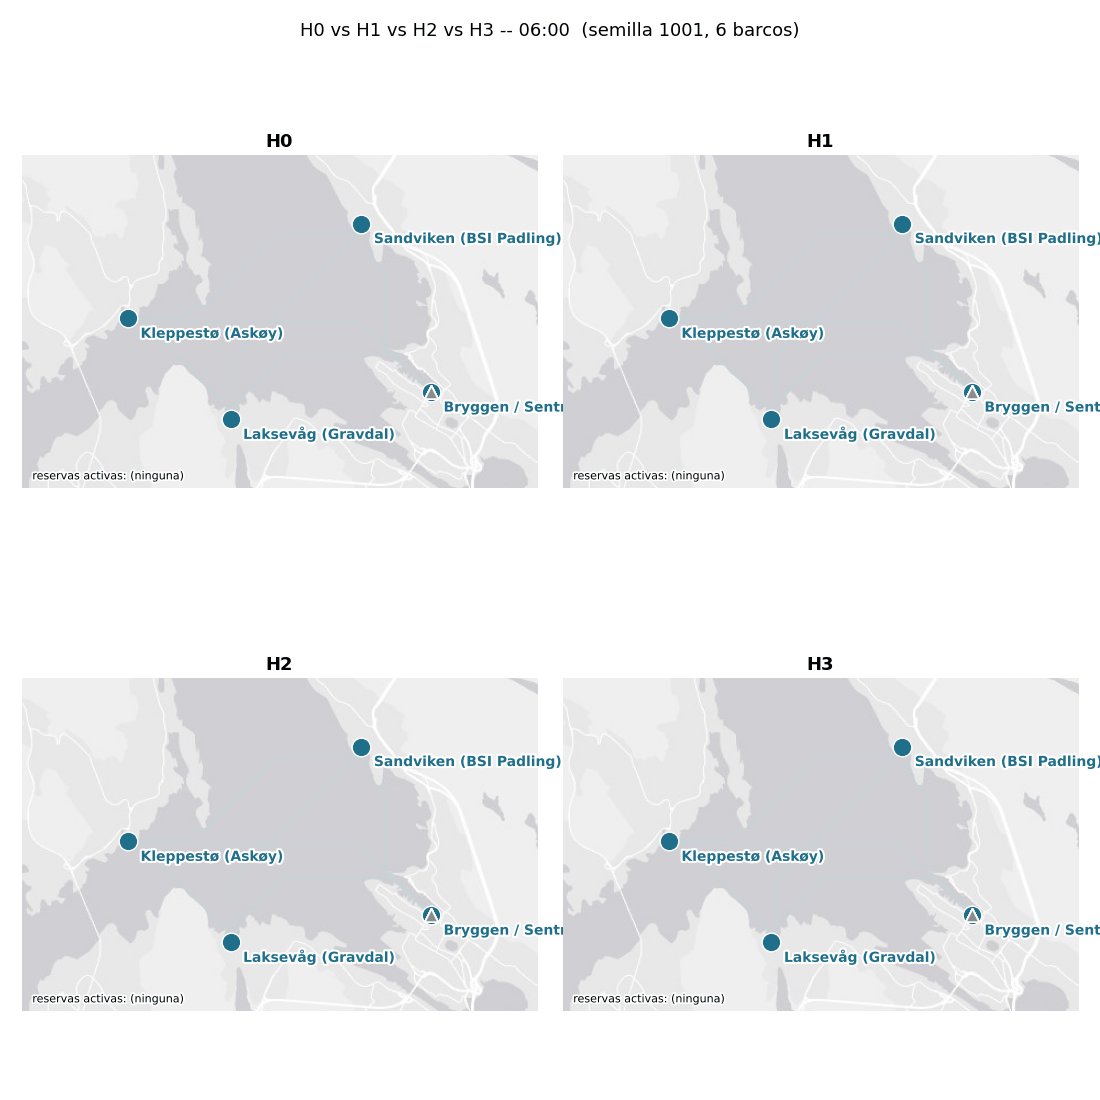

In [4]:
from IPython.display import Image
Image(filename=str(out_gif))

## GIFs individuales, uno por política

Mismo dibujo, un panel por archivo -- útil para mirar una sola política de
cerca (más grande, más fps) en vez de las 4 a la vez.

In [5]:
rutas_gif_individual = {}
for pol in POLITICAS:
    env, res_hist = datos[pol]
    fig_i, ax_i = plt.subplots(figsize=(7, 7))

    def _actualizar_individual(i, pol=pol, env=env, res_hist=res_hist, ax_i=ax_i):
        frame = env.historial_estados[i]
        viz.dibujar_frame(ax_i, frame, gdf_nodos, gdf_rutas, matriz_tiempos, capacidad, fondo=fondo)
        ax_i.text(0.02, 0.02, _texto_reservas(res_hist[i]), transform=ax_i.transAxes, fontsize=9,
                  va="bottom", ha="left", path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    fig_i.subplots_adjust(left=0.01, right=0.99, top=0.94, bottom=0.01)
    anim_i = FuncAnimation(fig_i, _actualizar_individual, frames=len(env.historial_estados), interval=1000 / 5)
    out_i = BASE / "heuristicas" / "outputs" / "figuras" / f"animacion_{pol}.gif"
    anim_i.save(out_i, writer=PillowWriter(fps=5))
    plt.close(fig_i)
    rutas_gif_individual[pol] = out_i
    print(f"{pol}: {out_i}")

H0: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\heuristicas\outputs\figuras\animacion_H0.gif


H1: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\heuristicas\outputs\figuras\animacion_H1.gif


H2: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\heuristicas\outputs\figuras\animacion_H2.gif


H3: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\heuristicas\outputs\figuras\animacion_H3.gif


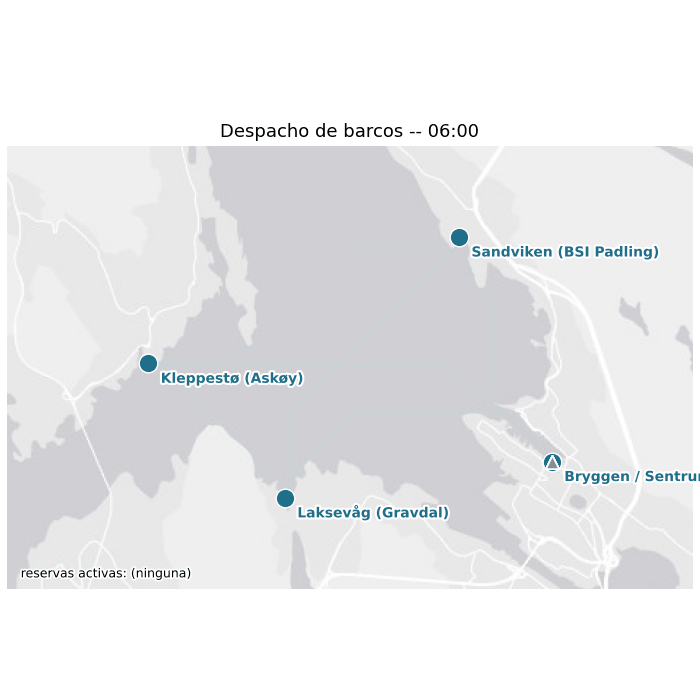

In [6]:
Image(filename=str(rutas_gif_individual["H3"]))  # cambiar la clave para ver otra politica

## Reproductor interactivo, paso a paso (requiere kernel vivo)

`visualizacion.reproductor_interactivo` -- botón play/pausa, barra de tiempo
para saltar a cualquier paso, mapa + panel de texto con barcos/colas/decisión
de ESE paso. **Solo responde si este notebook se abre con un kernel de
Jupyter vivo** (VS Code / Jupyter Lab) -- en la versión ya ejecutada y
guardada (como queda tras `nbconvert`), los controles no tienen nada
corriendo detrás y no van a reaccionar. Para inspección puntual sin depender
de un kernel vivo, usar `explicar_decision` más abajo, que sí queda
guardado con su resultado.

In [7]:
# Ejemplo -- cambiar "H3" por cualquier otra politica. Interactivo SOLO con kernel vivo.
env_h3, _ = datos["H3"]
viz.reproductor_interactivo(env_h3, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo)

## Inspector de decisión: qué calculó la política, no solo qué decidió

Para un barco libre en un minuto concreto, arma la tabla de TODOS los
candidatos que la política evaluó (par, gente esperando, espera de la más
antigua, tiempo de pickup, y el costo cuando aplica), marca cuál se eligió,
y lo compara contra el evento de decisión ya registrado en
`env.log_eventos`. Construido directamente sobre `env.historial_estados` +
`matriz_tiempos` -- no repite ninguna simulación, solo hace explícito el
cálculo que la política ya hizo.

In [8]:
def explicar_decision(pol: str, minuto: float, barco_idx: int | None = None):
    env, res_hist = datos[pol]
    frame = viz._frame_mas_cercano(env, minuto)
    idx0 = env.historial_estados.index(frame)

    # Si en el minuto pedido no hay NINGUN barco libre, esta funcion no
    # tendria nada que mostrar (nadie recibe una decision ese paso) --
    # busca el siguiente paso con al menos un barco libre en vez de
    # quedarse en silencio sin avisar.
    idx = idx0
    while idx < len(env.historial_estados) and not any(b["libre"] for b in env.historial_estados[idx]["barcos"]):
        idx += 1
    if idx >= len(env.historial_estados):
        print(f"{pol}: ningun barco quedo libre desde el minuto {minuto} en adelante en esta ventana.")
        return
    frame = env.historial_estados[idx]
    if idx != idx0:
        print(f"(ningun barco libre en el minuto {minuto:.0f} -- mostrando el siguiente paso con uno libre)")
    t = frame["tiempo"]["minuto_del_dia"]
    decisiones = [e for e in env.log_eventos if e["tipo"] == "decision" and abs(e["minuto"] - t) < 1e-6]

    for i, b in enumerate(frame["barcos"]):
        if not b["libre"]:
            continue
        if barco_idx is not None and i != barco_idx:
            continue
        barco_id = f"barco_{i}"
        nodo_id = viz.CODIGO_A_ID[b["origen"]]
        dec = next((d["decision"] for d in decisiones if d["barco_id"] == barco_id), None)

        filas = []
        for clave, v in frame["demanda"].items():
            if v["personas"] == 0:
                continue
            o_cod, d_cod = clave.split("->")
            o_id, d_id = viz.CODIGO_A_ID[o_cod], viz.CODIGO_A_ID[d_cod]
            pickup = float(matriz_tiempos.loc[nodo_id, o_id])
            es_local = o_id == nodo_id
            costo = round(pickup - v["espera_max"], 2) if pol in ("H2", "H3") else None
            filas.append({
                "par": f"{o_id}->{d_id}", "local": es_local, "personas": v["personas"],
                "espera_max_min": v["espera_max"], "pickup_min": round(pickup, 1), "costo": costo,
            })
        tabla = pd.DataFrame(filas)
        if not tabla.empty:
            if pol in ("H0", "H1"):
                tabla = tabla.sort_values(["local", "espera_max_min"], ascending=[False, False])
            elif pol == "H2":
                tabla = tabla.sort_values(["local", "costo"], ascending=[False, True])
            else:  # H3 -- sin particion, un solo orden global
                tabla = tabla.sort_values("costo", ascending=True)
            tabla["elegido"] = tabla["par"].apply(lambda p: p == dec)

        print(f"=== {pol} -- minuto {t:.0f} -- {barco_id} libre en {nodo_id} ===")
        print(f"decision registrada: {dec!r}")
        display(tabla if not tabla.empty else "(sin candidatos -- nadie esperando en ningun lado)")

explicar_decision("H3", minuto=HORA_INICIO_MIN + 20)

(ningun barco libre en el minuto 380 -- mostrando el siguiente paso con uno libre)
=== H3 -- minuto 382 -- barco_0 libre en bryggen ===
decision registrada: 'sandviken'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
4,bryggen->sandviken,True,6,5.7,0.0,-5.70,False
1,kleppesto->sandviken,False,23,14.6,11.5,-3.10,False
3,bryggen->kleppesto,True,11,1.9,0.0,-1.90,False
2,laksevag->bryggen,False,43,9.6,8.6,-0.99,False
5,sandviken->laksevag,False,13,4.2,6.8,2.63,False
6,sandviken->bryggen,False,7,3.1,6.8,3.73,False
0,kleppesto->bryggen,False,13,3.3,11.5,8.20,False


In [9]:
explicar_decision("H0", minuto=HORA_INICIO_MIN + 20)  # mismo minuto, comparar la regla lexicografica vs. el costo de H3

(ningun barco libre en el minuto 380 -- mostrando el siguiente paso con uno libre)
=== H0 -- minuto 382 -- barco_0 libre en bryggen ===
decision registrada: 'laksevag'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
5,bryggen->laksevag,True,24,15.3,0.0,None,False
6,bryggen->sandviken,True,6,5.7,0.0,None,False
4,bryggen->kleppesto,True,11,1.9,0.0,None,False
8,sandviken->bryggen,False,36,20.9,6.8,None,False
1,kleppesto->bryggen,False,68,20.5,11.5,None,False
0,kleppesto->laksevag,False,9,17.4,11.5,None,False
2,kleppesto->sandviken,False,23,14.6,11.5,None,False
3,laksevag->bryggen,False,46,9.6,8.6,None,False
7,sandviken->laksevag,False,13,4.2,6.8,None,False


=== H0 -- minuto 382 -- barco_1 libre en bryggen ===
decision registrada: 'sandviken'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
5,bryggen->laksevag,True,24,15.3,0.0,None,False
6,bryggen->sandviken,True,6,5.7,0.0,None,False
4,bryggen->kleppesto,True,11,1.9,0.0,None,False
8,sandviken->bryggen,False,36,20.9,6.8,None,False
1,kleppesto->bryggen,False,68,20.5,11.5,None,False
0,kleppesto->laksevag,False,9,17.4,11.5,None,False
2,kleppesto->sandviken,False,23,14.6,11.5,None,False
3,laksevag->bryggen,False,46,9.6,8.6,None,False
7,sandviken->laksevag,False,13,4.2,6.8,None,False


=== H0 -- minuto 382 -- barco_2 libre en sandviken ===
decision registrada: 'bryggen'


...

,par,local,personas,espera_max_min,pickup_min,costo,elegido
8,sandviken->bryggen,True,36,20.9,0.0,None,False
7,sandviken->laksevag,True,13,4.2,0.0,None,False
1,kleppesto->bryggen,False,68,20.5,9.6,None,False
0,kleppesto->laksevag,False,9,17.4,9.6,None,False
5,bryggen->laksevag,False,24,15.3,6.8,None,False
2,kleppesto->sandviken,False,23,14.6,9.6,None,False
3,laksevag->bryggen,False,46,9.6,8.6,None,False
6,bryggen->sandviken,False,6,5.7,6.8,None,False
4,bryggen->kleppesto,False,11,1.9,6.8,None,False


=== H0 -- minuto 382 -- barco_4 libre en sandviken ===
decision registrada: 'bryggen'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
8,sandviken->bryggen,True,36,20.9,0.0,None,False
7,sandviken->laksevag,True,13,4.2,0.0,None,False
1,kleppesto->bryggen,False,68,20.5,9.6,None,False
0,kleppesto->laksevag,False,9,17.4,9.6,None,False
5,bryggen->laksevag,False,24,15.3,6.8,None,False
2,kleppesto->sandviken,False,23,14.6,9.6,None,False
3,laksevag->bryggen,False,46,9.6,8.6,None,False
6,bryggen->sandviken,False,6,5.7,6.8,None,False
4,bryggen->kleppesto,False,11,1.9,6.8,None,False


=== H0 -- minuto 382 -- barco_5 libre en sandviken ===
decision registrada: 'kleppesto'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
8,sandviken->bryggen,True,36,20.9,0.0,None,False
7,sandviken->laksevag,True,13,4.2,0.0,None,False
1,kleppesto->bryggen,False,68,20.5,9.6,None,False
0,kleppesto->laksevag,False,9,17.4,9.6,None,False
5,bryggen->laksevag,False,24,15.3,6.8,None,False
2,kleppesto->sandviken,False,23,14.6,9.6,None,False
3,laksevag->bryggen,False,46,9.6,8.6,None,False
6,bryggen->sandviken,False,6,5.7,6.8,None,False
4,bryggen->kleppesto,False,11,1.9,6.8,None,False


In [10]:
explicar_decision("H2", minuto=HORA_INICIO_MIN + 40)

=== H2 -- minuto 400 -- barco_0 libre en laksevag ===
decision registrada: 'kleppesto'


,par,local,personas,espera_max_min,pickup_min,costo,elegido
1,laksevag->kleppesto,True,25,16.6,0.0,-16.60,False
2,laksevag->bryggen,True,61,16.3,0.0,-16.30,False
0,kleppesto->bryggen,False,72,15.9,5.3,-10.57,False
3,sandviken->kleppesto,False,15,12.6,8.6,-3.99,False
4,sandviken->bryggen,False,29,9.5,8.6,-0.89,False


## Interpretación

Comparando `explicar_decision("H3", ...)` contra `explicar_decision("H0", ...)`
en el mismo minuto: H0 ordena SOLO por espera dentro de lo local (columna
`costo` vacía, ni siquiera se calcula); H3 muestra el costo de TODOS los
candidatos, locales y remotos, en la misma tabla -- así se puede ver, para
ese barco y ese minuto exactos, si el candidato remoto más barato hubiera
podido ganarle al local si hubiera estado un poco más urgente (columna
`costo`, hay que superar el del mejor local).